In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def gen_matrix(arr, p1, p2): 
    alpha1, alpha2 = np.random.uniform(0, 2 * np.pi), np.random.uniform(0, 2 * np.pi)
    
    t1, t2 = np.cos(alpha1) + 1j * np.sin(alpha1), np.cos(alpha2) + 1j * np.sin(alpha2)

    arr[*p1] = t1
    arr[*p2] = t2

    return arr

def gen_base_matrix(n, values):
    arr = np.zeros((n, n), dtype=complex)
    for x in range(n):
        for y in range(n): 
            arr[x, y] = np.random.choice(values)

    return arr

In [ ]:
with open('data.csv', 'w') as f:
    N = 4
    values=[0, -1, 1, -1j, 1j]

    arr = gen_base_matrix(N, values)

    p1 = np.random.randint(0, N, size=2)
    p2 = np.random.randint(0, N, size=2)

    print(p1, p2)
    print(arr)

    batch_counter = 0

    for i in range(2_00_000):
        matrix = gen_matrix(arr, p1, p2)

        lambdas = np.linalg.eigvals(matrix)
        
        # lambdas = [lambd for lambd in lambdas if lambd.imag != 0]
        
        for lambd in lambdas:
            f.write(f"{lambd.real:.6f},{lambd.imag:.6f}\n")
        
        batch_counter += len(lambdas)

[1 3] [1 1]
[[ 1.+0.j  0.+0.j  1.+0.j  0.+1.j]
 [-1.+0.j  0.+0.j  0.+1.j  0.+0.j]
 [ 0.+1.j  1.+0.j  0.+0.j  0.+1.j]
 [-0.-1.j  0.+0.j -0.-1.j  0.+1.j]]


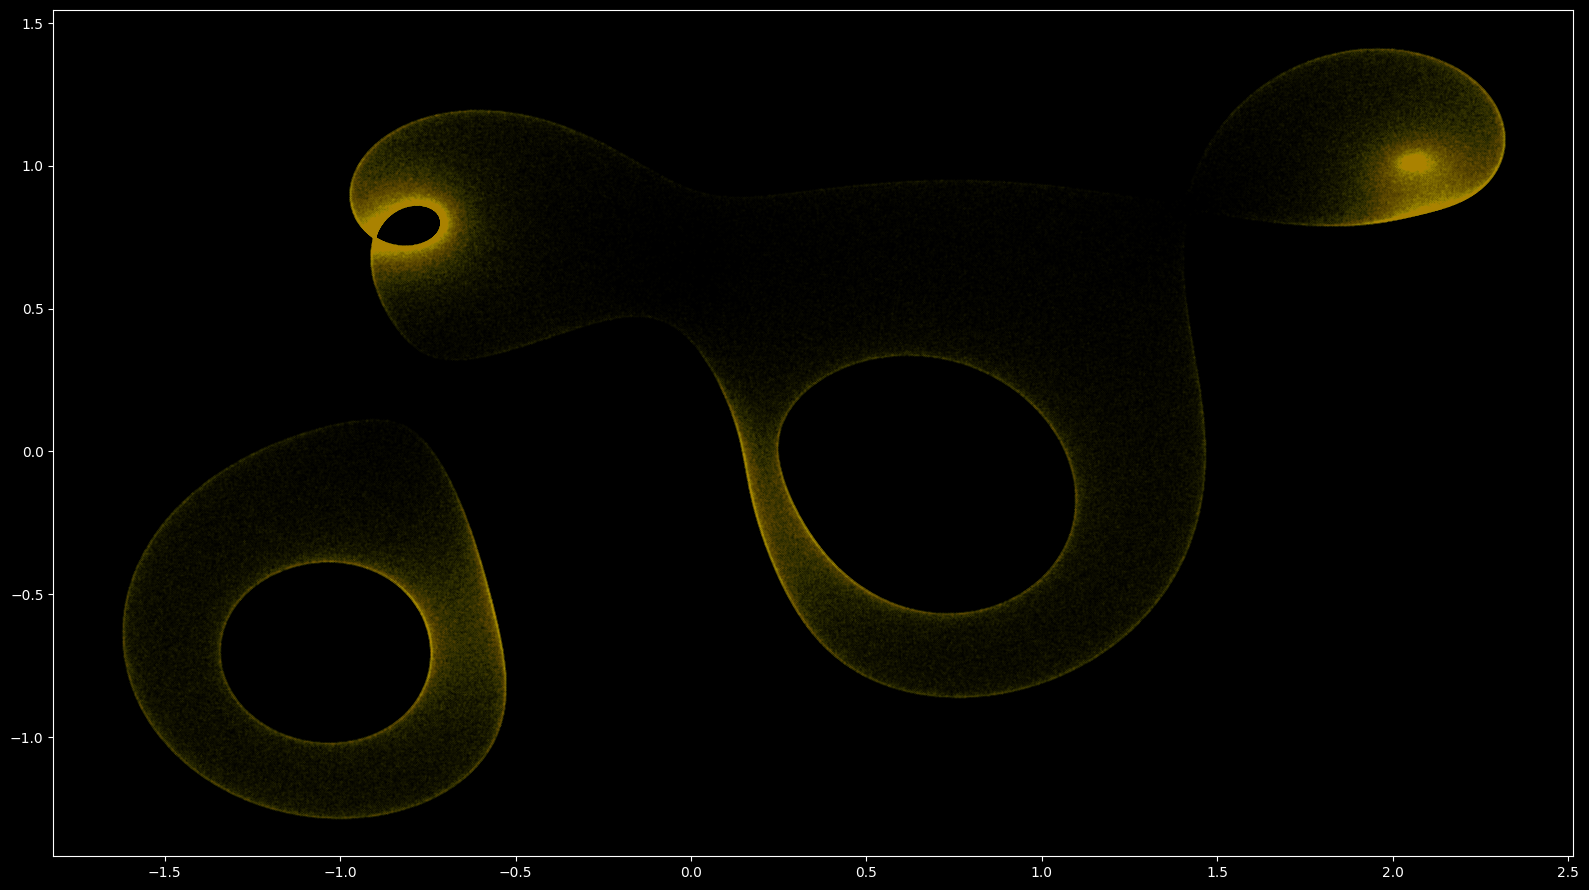

In [ ]:
plt.figure(figsize=(16, 9))

color = 'gold'
edgecolors = color

alpha = 0.03
s = 0.1

try:
    data = np.loadtxt('data.csv', delimiter=',')
    if len(data) > 0:
        real_parts = data[:, 0]
        imag_parts = data[:, 1]

        plt.scatter(real_parts, imag_parts, color=color, alpha=alpha, s=s, edgecolors=edgecolors)
        
except MemoryError:
    chunk_size = 100_000
    all_data = []
    
    with open('data.csv', 'r') as f:
        chunk = []
        for line in f:
            parts = line.strip().split(',')
            if len(parts) == 2:
                chunk.append([float(parts[0]), float(parts[1])])
            
            if len(chunk) >= chunk_size:
                chunk_arr = np.array(chunk)
                plt.scatter(chunk_arr[:, 0], chunk_arr[:, 1], color=color, alpha=alpha, s=s, edgecolors=edgecolors)
                chunk = []
        
        if chunk:
            chunk_arr = np.array(chunk)
            plt.scatter(chunk_arr[:, 0], chunk_arr[:, 1], color=color, alpha=alpha, s=s, edgecolors=edgecolors)

# plt.xlim(-3, 3)
# plt.ylim(-3, 3)

# plt.axis('off')

plt.tight_layout()
plt.savefig('output/eigenvalues.png', dpi=200)
